In [1]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline


#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.tools.layout_functions import visualize_layout
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

In [13]:
df_wind_montly = pd.read_csv('../2020_Daily_Avgs.csv')
df_wind_montly.head()

list_wd_bins = [0., 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80., 85., 90., 95., 100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260., 265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315., 320., 325., 330., 335., 340., 345., 350., 355.]

list_ws_bins = [0., 1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.]

windr = WindRose()

df_wind_calc = windr.make_wind_rose_from_user_data(wd_raw=df_wind_montly['average_wind_dir_deg'], ws_raw=df_wind_montly['Factorized_Mean'], wd=np.array(list_wd_bins), ws=np.array(list_ws_bins))


wd_array = np.array(df_wind_calc["wd"].unique(), dtype=float)
ws_array = np.array(df_wind_calc["ws"].unique(), dtype=float)


wd_grid, ws_grid = np.meshgrid(wd_array, ws_array, indexing="ij")
freq_interp = NearestNDInterpolator(df_wind_calc[["wd", "ws"]], df_wind_calc["freq_val"])
freq = freq_interp(wd_grid, ws_grid)

# Normalize the frequency array to sum to exactly 1.0
freq = freq / np.sum(freq)

Correcting negative Overhang:-2.5


In [5]:
df_vestas = pd.read_csv('../pop_fav.csv')
df_nrel = pd.read_csv('../gen_2_13.csv')

In [6]:
v_p_with_wake = []
v_p_without_wake = []
v_loss = []
n_p_with_wake = []
n_p_without_wake = []
n_loss = []

In [14]:
def aep_powers(fi, df_vestas):
    power_list = []
    fi.reinitialize(
        layout_x=df_vestas['Layout_x'],
        layout_y=df_vestas['Layout_y'],
        wind_directions=wd_array,
        wind_speeds=ws_array,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list

#### Vestas Power with change in rotor diameter

In [ ]:
import ruamel.yaml

def update_yaml(rotor_diameter):
    # Load the YAML file
    yaml = ruamel.yaml.YAML()
    with open('Vesta_V52-0.85.yaml', 'r') as file:
        data = yaml.load(file)

    # Modify the value
    data['rotor_diameter'] = rotor_diameter

    # Write the file back out
    with open('Vesta_V52-0.85.yaml', 'w') as file:
        yaml.dump(data, file)

r = [i for i in range(52, 127, 2)]
v_p_with_wake = []
v_p_without_wake = []
v_loss = []

for rotor_diameter in r:
    update_yaml(rotor_diameter)
    fi_vestas_powers = FlorisInterface("./gch_vestas.yaml")
    result = aep_powers(fi_vestas_powers, df_vestas)
    v_p_with_wake.append(result[0])
    v_p_without_wake.append(result[1])
    v_loss.append(result[2])

#### Nrel Power with change in rotor diameter

In [33]:
import ruamel.yaml

def update_yaml(rotor_diameter):
    # Load the YAML file
    yaml = ruamel.yaml.YAML()
    with open('nrel_turbine.yaml', 'r') as file:
        data = yaml.load(file)

    # Modify the value
    data['rotor_diameter'] = rotor_diameter

    # Write the file back out
    with open('nrel_turbine.yaml', 'w') as file:
        yaml.dump(data, file)

r = [i for i in range(52, 127, 2)]
n_p_with_wake = []
n_p_without_wake = []
n_loss = []

for rotor_diameter in r:
    update_yaml(rotor_diameter)
    fi_nrel_powers = FlorisInterface("./nrel_jensen.yaml")
    result_n = aep_powers(fi_nrel_powers, df_nrel)
    n_p_with_wake.append(result_n[0])
    n_p_without_wake.append(result_n[1])
    n_loss.append(result_n[2])

#### Plots

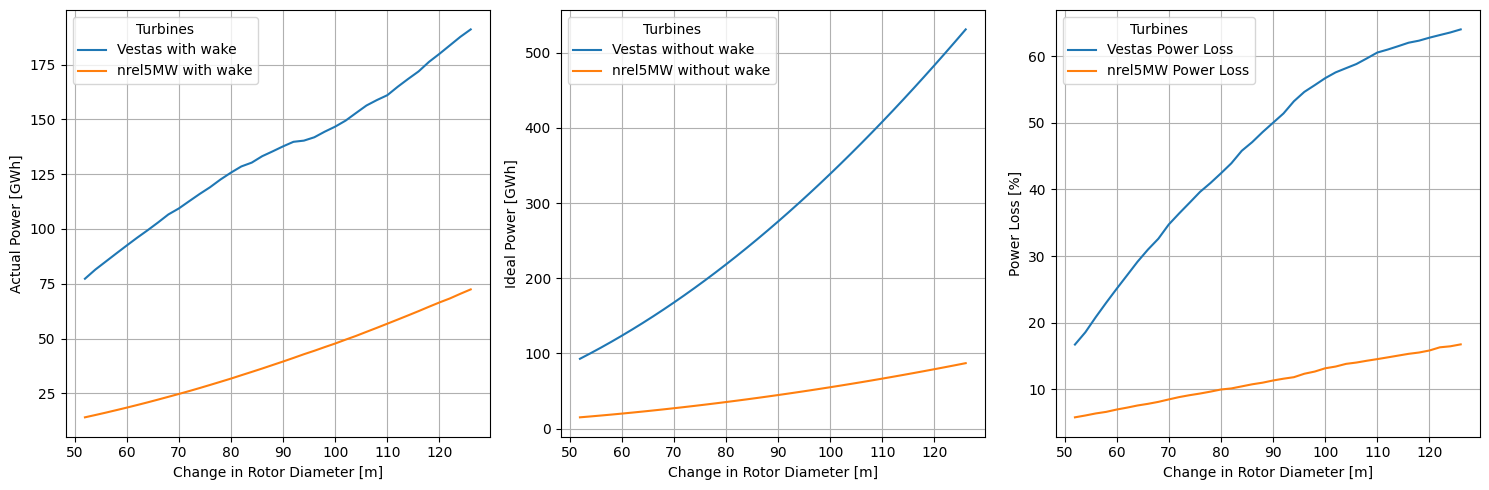

In [39]:
fig, axarr = plt.subplots(1, 3, figsize=(15, 5))

# Plot Actual Power
ax = axarr[0]
ax.plot(r, v_p_with_wake, label='Vestas with wake')
ax.plot(r, n_p_with_wake, label='nrel5MW with wake')
ax.set_xlabel('Change in Rotor Diameter [m]')
ax.set_ylabel('Actual Power [GWh]')
ax.legend(title="Turbines",)
ax.grid()
# Plot Ideal Power
ax = axarr[1]
ax.plot(r, v_p_without_wake, label='Vestas without wake')
ax.plot(r, n_p_without_wake, label='nrel5MW without wake')
ax.set_xlabel('Change in Rotor Diameter [m]')
ax.set_ylabel('Ideal Power [GWh]')
ax.legend(title="Turbines",)
ax.grid()

# Plot Power Loss
ax = axarr[2]
ax.plot(r, v_loss, label="Vestas Power Loss")
ax.plot(r, n_loss, label="nrel5MW Power Loss")
ax.set_xlabel('Change in Rotor Diameter [m]')
ax.set_ylabel('Power Loss [%]')
ax.legend(
    title="Turbines",
)
ax.grid()

plt.tight_layout()

plt.show()